<a href="https://colab.research.google.com/github/shashank3110/genAI/blob/main/langgraph_edw_agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install -U langgraph langchain_google_genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.4/236.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.8/68.8 kB 6.2 MB/s eta 0:00:00
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.2.1
    Uninstalling langgraph-1.2.1:
      Successfully uninstalled langgraph-1.2.1


In [1]:
pip install faiss-cpu langchain-community


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.4 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [3]:
import os
os.environ["GOOGLE_API_KEY"]="" # ADD API key

In [4]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain.tools import tool
from langchain.chat_models import init_chat_model
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph
from typing import TypedDict, List
from langchain_core.messages import BaseMessage
import pandas as pd

### Sample Knowledge base data: as a dict/json

In [5]:
"""
Data Warehouse Documentation Metadata
Scraped from internal DWH documentation portal.
Structure: one entry per documentation page, keyed by object name.
Each entry contains:
  - page_title   : display name of the table / view
  - url          : canonical documentation URL identifying object type and name
  - object_type  : 'fact' | 'dimension' | 'derived_view'
  - description  : full-text description from the page
  - attributes   : list of column metadata dicts
                   { column_name, data_type, description }
"""
DWH_METADATA = {

    # ──────────────────────────────────────────────────────────────
    # FACT TABLES
    # ──────────────────────────────────────────────────────────────

    "fact_sales_transactions": {
        "page_title": "Fact: Sales Transactions",
        "url": "https://dwh-docs.internal/facts/sales_transactions",
        "object_type": "fact",
        "description": (
            "Grain-level record of every sales transaction processed across all channels "
            "(online, retail, wholesale). Each row represents one line item on an order. "
            "Used as the primary source of truth for revenue reporting and sales analytics."
        ),
        "attributes": [
            {"column_name": "transaction_sk",    "data_type": "BIGINT",      "description": "Surrogate key, primary key of this fact table"},
            {"column_name": "order_id",          "data_type": "VARCHAR(36)", "description": "Natural key linking rows to the same order"},
            {"column_name": "date_sk",           "data_type": "INT",         "description": "FK to dim_date"},
            {"column_name": "customer_sk",       "data_type": "INT",         "description": "FK to dim_customer"},
            {"column_name": "product_sk",        "data_type": "INT",         "description": "FK to dim_product"},
            {"column_name": "store_sk",          "data_type": "INT",         "description": "FK to dim_store"},
            {"column_name": "quantity_sold",     "data_type": "INT",         "description": "Number of units sold in this line item"},
            {"column_name": "unit_price",        "data_type": "DECIMAL(12,4)","description": "Selling price per unit at time of transaction"},
            {"column_name": "discount_amount",   "data_type": "DECIMAL(10,2)","description": "Total discount applied to this line item"},
            {"column_name": "net_revenue",       "data_type": "DECIMAL(14,2)","description": "Revenue after discounts; quantity × unit_price − discount_amount"},
            {"column_name": "cost_of_goods",     "data_type": "DECIMAL(14,2)","description": "COGS for this line item from ERP"},
            {"column_name": "gross_margin",      "data_type": "DECIMAL(14,2)","description": "net_revenue − cost_of_goods"},
            {"column_name": "channel_code",      "data_type": "VARCHAR(20)", "description": "Sales channel: ONLINE | RETAIL | WHOLESALE"},
            {"column_name": "currency_code",     "data_type": "CHAR(3)",     "description": "ISO 4217 currency of the transaction"},
            {"column_name": "loaded_at",         "data_type": "TIMESTAMP",   "description": "ETL load timestamp (UTC)"},
        ],
    },

    "fact_web_sessions": {
        "page_title": "Fact: Web Sessions",
        "url": "https://dwh-docs.internal/facts/web_sessions",
        "object_type": "fact",
        "description": (
            "One row per user session captured by the website analytics pipeline. "
            "Tracks session-level engagement metrics such as page views, bounce events, "
            "and conversion actions. Sourced from the raw event stream via dbt."
        ),
        "attributes": [
            {"column_name": "session_sk",        "data_type": "BIGINT",      "description": "Surrogate primary key"},
            {"column_name": "session_id",        "data_type": "VARCHAR(64)", "description": "Raw session identifier from analytics SDK"},
            {"column_name": "date_sk",           "data_type": "INT",         "description": "FK to dim_date (session start date)"},
            {"column_name": "customer_sk",       "data_type": "INT",         "description": "FK to dim_customer; NULL for anonymous sessions"},
            {"column_name": "device_sk",         "data_type": "INT",         "description": "FK to dim_device"},
            {"column_name": "campaign_sk",       "data_type": "INT",         "description": "FK to dim_campaign; NULL if direct traffic"},
            {"column_name": "session_start_ts",  "data_type": "TIMESTAMP",   "description": "UTC timestamp when session began"},
            {"column_name": "session_end_ts",    "data_type": "TIMESTAMP",   "description": "UTC timestamp when session ended or timed out"},
            {"column_name": "duration_seconds",  "data_type": "INT",         "description": "Total session length in seconds"},
            {"column_name": "page_view_count",   "data_type": "INT",         "description": "Number of page views within the session"},
            {"column_name": "is_bounce",         "data_type": "BOOLEAN",     "description": "True if session had only one page view"},
            {"column_name": "converted",         "data_type": "BOOLEAN",     "description": "True if a purchase event occurred in session"},
            {"column_name": "revenue_attributed","data_type": "DECIMAL(14,2)","description": "Revenue from any order placed during session"},
        ],
    },

    "fact_inventory_movements": {
        "page_title": "Fact: Inventory Movements",
        "url": "https://dwh-docs.internal/facts/inventory_movements",
        "object_type": "fact",
        "description": (
            "Records every inventory movement event (receipt, transfer, adjustment, sale) "
            "across all warehouses and retail locations. Grain is one movement per product "
            "per location per event. Used for stock-level analysis and shrinkage reporting."
        ),
        "attributes": [
            {"column_name": "movement_sk",       "data_type": "BIGINT",      "description": "Surrogate primary key"},
            {"column_name": "movement_type",     "data_type": "VARCHAR(30)", "description": "RECEIPT | SALE | TRANSFER_IN | TRANSFER_OUT | ADJUSTMENT"},
            {"column_name": "date_sk",           "data_type": "INT",         "description": "FK to dim_date"},
            {"column_name": "product_sk",        "data_type": "INT",         "description": "FK to dim_product"},
            {"column_name": "location_sk",       "data_type": "INT",         "description": "FK to dim_location"},
            {"column_name": "quantity_delta",    "data_type": "INT",         "description": "Units added (positive) or removed (negative)"},
            {"column_name": "unit_cost",         "data_type": "DECIMAL(12,4)","description": "Cost per unit at time of movement"},
            {"column_name": "total_cost",        "data_type": "DECIMAL(14,2)","description": "quantity_delta × unit_cost"},
            {"column_name": "reference_id",      "data_type": "VARCHAR(64)", "description": "Source document ID (PO number, transfer ID, etc.)"},
            {"column_name": "loaded_at",         "data_type": "TIMESTAMP",   "description": "ETL load timestamp (UTC)"},
        ],
    },

    "fact_customer_support_tickets": {
        "page_title": "Fact: Customer Support Tickets",
        "url": "https://dwh-docs.internal/facts/customer_support_tickets",
        "object_type": "fact",
        "description": (
            "One row per support ticket lifecycle event (creation, update, resolution). "
            "Supports SLA compliance monitoring, CSAT tracking, and agent performance reporting. "
            "Source system is Zendesk, ingested hourly."
        ),
        "attributes": [
            {"column_name": "ticket_event_sk",   "data_type": "BIGINT",      "description": "Surrogate primary key"},
            {"column_name": "ticket_id",         "data_type": "BIGINT",      "description": "Natural key from Zendesk"},
            {"column_name": "event_type",        "data_type": "VARCHAR(20)", "description": "CREATED | UPDATED | RESOLVED | REOPENED"},
            {"column_name": "date_sk",           "data_type": "INT",         "description": "FK to dim_date (event date)"},
            {"column_name": "customer_sk",       "data_type": "INT",         "description": "FK to dim_customer"},
            {"column_name": "agent_sk",          "data_type": "INT",         "description": "FK to dim_employee (handling agent)"},
            {"column_name": "category_code",     "data_type": "VARCHAR(50)", "description": "Ticket category from taxonomy"},
            {"column_name": "priority",          "data_type": "VARCHAR(10)", "description": "LOW | NORMAL | HIGH | URGENT"},
            {"column_name": "channel",           "data_type": "VARCHAR(20)", "description": "Submission channel: EMAIL | CHAT | PHONE | WEB"},
            {"column_name": "first_response_sec","data_type": "INT",         "description": "Seconds to first agent response; NULL if not yet responded"},
            {"column_name": "resolution_sec",    "data_type": "INT",         "description": "Seconds from creation to resolution; NULL if open"},
            {"column_name": "csat_score",        "data_type": "SMALLINT",    "description": "Customer satisfaction score 1-5; NULL if not rated"},
            {"column_name": "sla_breached",      "data_type": "BOOLEAN",     "description": "True if first_response_sec exceeded SLA threshold"},
        ],
    },

    "fact_marketing_spend": {
        "page_title": "Fact: Marketing Spend",
        "url": "https://dwh-docs.internal/facts/marketing_spend",
        "object_type": "fact",
        "description": (
            "Daily spend, impression, and click metrics per campaign per channel. "
            "Aggregated from Google Ads, Meta, LinkedIn, and programmatic DSPs. "
            "Grain is campaign × ad-group × date."
        ),
        "attributes": [
            {"column_name": "spend_sk",          "data_type": "BIGINT",      "description": "Surrogate primary key"},
            {"column_name": "date_sk",           "data_type": "INT",         "description": "FK to dim_date"},
            {"column_name": "campaign_sk",       "data_type": "INT",         "description": "FK to dim_campaign"},
            {"column_name": "platform_code",     "data_type": "VARCHAR(20)", "description": "GOOGLE | META | LINKEDIN | PROGRAMMATIC"},
            {"column_name": "ad_group_id",       "data_type": "VARCHAR(64)", "description": "Platform-native ad group identifier"},
            {"column_name": "impressions",       "data_type": "BIGINT",      "description": "Total impressions served"},
            {"column_name": "clicks",            "data_type": "INT",         "description": "Total clicks"},
            {"column_name": "spend_usd",         "data_type": "DECIMAL(12,2)","description": "Gross spend in USD"},
            {"column_name": "conversions",       "data_type": "INT",         "description": "Platform-reported conversion events"},
            {"column_name": "cpm",               "data_type": "DECIMAL(8,4)", "description": "Cost per thousand impressions"},
            {"column_name": "cpc",               "data_type": "DECIMAL(8,4)", "description": "Cost per click"},
            {"column_name": "roas",              "data_type": "DECIMAL(8,4)", "description": "Return on ad spend (platform-attributed revenue / spend)"},
        ],
    },

    "fact_employee_attendance": {
        "page_title": "Fact: Employee Attendance",
        "url": "https://dwh-docs.internal/facts/employee_attendance",
        "object_type": "fact",
        "description": (
            "Daily attendance record per employee. Captures scheduled vs. actual hours, "
            "leave events, and overtime. Sourced from the workforce management system. "
            "Used by HR analytics and payroll reconciliation."
        ),
        "attributes": [
            {"column_name": "attendance_sk",     "data_type": "BIGINT",      "description": "Surrogate primary key"},
            {"column_name": "date_sk",           "data_type": "INT",         "description": "FK to dim_date"},
            {"column_name": "employee_sk",       "data_type": "INT",         "description": "FK to dim_employee"},
            {"column_name": "department_sk",     "data_type": "INT",         "description": "FK to dim_department"},
            {"column_name": "scheduled_hours",   "data_type": "DECIMAL(5,2)","description": "Planned work hours for the day"},
            {"column_name": "actual_hours",      "data_type": "DECIMAL(5,2)","description": "Actual hours clocked in (from badge/timeclock)"},
            {"column_name": "overtime_hours",    "data_type": "DECIMAL(5,2)","description": "Hours beyond standard threshold (default: 8h/day)"},
            {"column_name": "leave_type",        "data_type": "VARCHAR(30)", "description": "NULL if worked; SICK | VACATION | UNPAID | PUBLIC_HOLIDAY"},
            {"column_name": "absence_flag",      "data_type": "BOOLEAN",     "description": "True if employee was absent without approved leave"},
        ],
    },

    "fact_financial_postings": {
        "page_title": "Fact: Financial Postings",
        "url": "https://dwh-docs.internal/facts/financial_postings",
        "object_type": "fact",
        "description": (
            "General-ledger posting records from SAP. Each row is one journal-entry line. "
            "Supports P&L, balance sheet, and cash-flow reporting in the BI layer. "
            "Fiscal calendar alignment handled via dim_date fiscal attributes."
        ),
        "attributes": [
            {"column_name": "posting_sk",        "data_type": "BIGINT",      "description": "Surrogate primary key"},
            {"column_name": "posting_date_sk",   "data_type": "INT",         "description": "FK to dim_date (accounting date)"},
            {"column_name": "document_number",   "data_type": "VARCHAR(20)", "description": "SAP document number"},
            {"column_name": "gl_account_sk",     "data_type": "INT",         "description": "FK to dim_gl_account"},
            {"column_name": "cost_center_sk",    "data_type": "INT",         "description": "FK to dim_cost_center"},
            {"column_name": "debit_amount",      "data_type": "DECIMAL(18,2)","description": "Debit value in local currency; 0 if credit posting"},
            {"column_name": "credit_amount",     "data_type": "DECIMAL(18,2)","description": "Credit value in local currency; 0 if debit posting"},
            {"column_name": "currency_code",     "data_type": "CHAR(3)",     "description": "ISO 4217 local currency"},
            {"column_name": "amount_usd",        "data_type": "DECIMAL(18,2)","description": "Amount converted to USD using daily FX rate"},
            {"column_name": "fiscal_period",     "data_type": "CHAR(7)",     "description": "Company fiscal period, format YYYY-PPP"},
            {"column_name": "reversal_flag",     "data_type": "BOOLEAN",     "description": "True if this posting reverses a prior entry"},
        ],
    },

    "fact_product_returns": {
        "page_title": "Fact: Product Returns",
        "url": "https://dwh-docs.internal/facts/product_returns",
        "object_type": "fact",
        "description": (
            "Captures every product return or refund event linked back to the originating "
            "sales transaction. Grain is one row per returned line item. "
            "Used to calculate return rate KPIs and identify defect hotspots."
        ),
        "attributes": [
            {"column_name": "return_sk",         "data_type": "BIGINT",      "description": "Surrogate primary key"},
            {"column_name": "return_date_sk",    "data_type": "INT",         "description": "FK to dim_date (return processed date)"},
            {"column_name": "original_transaction_sk","data_type": "BIGINT", "description": "FK to fact_sales_transactions"},
            {"column_name": "product_sk",        "data_type": "INT",         "description": "FK to dim_product"},
            {"column_name": "customer_sk",       "data_type": "INT",         "description": "FK to dim_customer"},
            {"column_name": "quantity_returned", "data_type": "INT",         "description": "Number of units returned"},
            {"column_name": "refund_amount",     "data_type": "DECIMAL(14,2)","description": "Total refund issued"},
            {"column_name": "return_reason_code","data_type": "VARCHAR(30)", "description": "Standardised reason: DEFECTIVE | WRONG_ITEM | CHANGED_MIND | OTHER"},
            {"column_name": "restocked_flag",    "data_type": "BOOLEAN",     "description": "True if returned unit was added back to sellable inventory"},
        ],
    },

    "fact_subscription_events": {
        "page_title": "Fact: Subscription Events",
        "url": "https://dwh-docs.internal/facts/subscription_events",
        "object_type": "fact",
        "description": (
            "Event-level record for every subscription lifecycle action: new, renewal, "
            "upgrade, downgrade, pause, and churn. Grain is one event per subscription. "
            "Foundation for MRR/ARR calculations and churn cohort analysis."
        ),
        "attributes": [
            {"column_name": "event_sk",          "data_type": "BIGINT",      "description": "Surrogate primary key"},
            {"column_name": "subscription_id",   "data_type": "VARCHAR(64)", "description": "Natural key from billing system"},
            {"column_name": "event_date_sk",     "data_type": "INT",         "description": "FK to dim_date"},
            {"column_name": "customer_sk",       "data_type": "INT",         "description": "FK to dim_customer"},
            {"column_name": "plan_sk",           "data_type": "INT",         "description": "FK to dim_subscription_plan"},
            {"column_name": "event_type",        "data_type": "VARCHAR(20)", "description": "NEW | RENEWAL | UPGRADE | DOWNGRADE | PAUSE | CHURN"},
            {"column_name": "mrr_before",        "data_type": "DECIMAL(12,2)","description": "Monthly recurring revenue before this event"},
            {"column_name": "mrr_after",         "data_type": "DECIMAL(12,2)","description": "Monthly recurring revenue after this event"},
            {"column_name": "mrr_delta",         "data_type": "DECIMAL(12,2)","description": "mrr_after − mrr_before (signed)"},
            {"column_name": "churn_reason_code", "data_type": "VARCHAR(40)", "description": "Populated for CHURN events only; NULL otherwise"},
        ],
    },

    "fact_supply_chain_orders": {
        "page_title": "Fact: Supply Chain Orders",
        "url": "https://dwh-docs.internal/facts/supply_chain_orders",
        "object_type": "fact",
        "description": (
            "Purchase-order line items from procurement to suppliers. Tracks ordered vs. "
            "received quantities and on-time delivery performance. "
            "Grain is one row per PO line."
        ),
        "attributes": [
            {"column_name": "po_line_sk",        "data_type": "BIGINT",      "description": "Surrogate primary key"},
            {"column_name": "po_number",         "data_type": "VARCHAR(30)", "description": "Purchase order number"},
            {"column_name": "po_line_number",    "data_type": "SMALLINT",    "description": "Line sequence within the PO"},
            {"column_name": "order_date_sk",     "data_type": "INT",         "description": "FK to dim_date (PO creation date)"},
            {"column_name": "expected_date_sk",  "data_type": "INT",         "description": "FK to dim_date (expected delivery date)"},
            {"column_name": "actual_date_sk",    "data_type": "INT",         "description": "FK to dim_date (actual delivery date); NULL if outstanding"},
            {"column_name": "supplier_sk",       "data_type": "INT",         "description": "FK to dim_supplier"},
            {"column_name": "product_sk",        "data_type": "INT",         "description": "FK to dim_product"},
            {"column_name": "quantity_ordered",  "data_type": "INT",         "description": "Units ordered"},
            {"column_name": "quantity_received", "data_type": "INT",         "description": "Units actually received; NULL if outstanding"},
            {"column_name": "unit_cost",         "data_type": "DECIMAL(12,4)","description": "Agreed unit cost in PO currency"},
            {"column_name": "total_cost",        "data_type": "DECIMAL(14,2)","description": "quantity_ordered × unit_cost"},
            {"column_name": "on_time_delivery",  "data_type": "BOOLEAN",     "description": "True if actual_date_sk <= expected_date_sk"},
        ],
    },


    # ──────────────────────────────────────────────────────────────
    # DIMENSION TABLES
    # ──────────────────────────────────────────────────────────────

    "dim_date": {
        "page_title": "Dimension: Date",
        "url": "https://dwh-docs.internal/dimensions/date",
        "object_type": "dimension",
        "description": (
            "Standard date dimension spanning 2010-01-01 to 2035-12-31. "
            "Pre-populated with Gregorian and fiscal calendar attributes. "
            "Fiscal year starts 1 October (FY = calendar year + 1)."
        ),
        "attributes": [
            {"column_name": "date_sk",           "data_type": "INT",         "description": "Surrogate key in YYYYMMDD format"},
            {"column_name": "full_date",         "data_type": "DATE",        "description": "Calendar date"},
            {"column_name": "day_of_week",       "data_type": "SMALLINT",    "description": "1 = Monday … 7 = Sunday (ISO)"},
            {"column_name": "day_name",          "data_type": "VARCHAR(10)", "description": "Full day name (Monday … Sunday)"},
            {"column_name": "week_of_year",      "data_type": "SMALLINT",    "description": "ISO week number (1–53)"},
            {"column_name": "month_number",      "data_type": "SMALLINT",    "description": "1–12"},
            {"column_name": "month_name",        "data_type": "VARCHAR(10)", "description": "Full month name"},
            {"column_name": "quarter",           "data_type": "SMALLINT",    "description": "Calendar quarter 1–4"},
            {"column_name": "year",              "data_type": "SMALLINT",    "description": "Calendar year"},
            {"column_name": "fiscal_period",     "data_type": "SMALLINT",    "description": "Fiscal period 1–12"},
            {"column_name": "fiscal_quarter",    "data_type": "SMALLINT",    "description": "Fiscal quarter 1–4"},
            {"column_name": "fiscal_year",       "data_type": "SMALLINT",    "description": "Fiscal year (Oct–Sep)"},
            {"column_name": "is_weekend",        "data_type": "BOOLEAN",     "description": "True for Saturday and Sunday"},
            {"column_name": "is_public_holiday", "data_type": "BOOLEAN",     "description": "True for public holidays (UK calendar)"},
        ],
    },

    "dim_customer": {
        "page_title": "Dimension: Customer",
        "url": "https://dwh-docs.internal/dimensions/customer",
        "object_type": "dimension",
        "description": (
            "SCD Type 2 dimension capturing the full history of customer attributes. "
            "Each row is a version of a customer record; current version flagged by is_current. "
            "Source: CRM system (Salesforce) merged with e-commerce account data."
        ),
        "attributes": [
            {"column_name": "customer_sk",       "data_type": "INT",         "description": "Surrogate primary key (versioned)"},
            {"column_name": "customer_id",       "data_type": "VARCHAR(36)", "description": "Natural/business key (UUID from CRM)"},
            {"column_name": "full_name",         "data_type": "VARCHAR(200)", "description": "Customer full name"},
            {"column_name": "email",             "data_type": "VARCHAR(320)", "description": "Primary email address (PII – masked in non-prod)"},
            {"column_name": "segment",           "data_type": "VARCHAR(30)", "description": "Marketing segment: B2C | SMB | ENTERPRISE"},
            {"column_name": "country_code",      "data_type": "CHAR(2)",     "description": "ISO 3166-1 alpha-2 country of residence"},
            {"column_name": "city",              "data_type": "VARCHAR(100)", "description": "City of residence"},
            {"column_name": "acquisition_channel","data_type": "VARCHAR(40)","description": "Channel through which the customer was acquired"},
            {"column_name": "loyalty_tier",      "data_type": "VARCHAR(20)", "description": "BRONZE | SILVER | GOLD | PLATINUM"},
            {"column_name": "valid_from",        "data_type": "DATE",        "description": "Date this version became effective"},
            {"column_name": "valid_to",          "data_type": "DATE",        "description": "Date this version was superseded; 9999-12-31 for current"},
            {"column_name": "is_current",        "data_type": "BOOLEAN",     "description": "True for the latest active version"},
        ],
    },

    "dim_product": {
        "page_title": "Dimension: Product",
        "url": "https://dwh-docs.internal/dimensions/product",
        "object_type": "dimension",
        "description": (
            "SCD Type 2 product catalogue dimension. Covers all SKUs currently or "
            "historically sold. Hierarchy: Category → Sub-category → Product → SKU. "
            "Source: ERP product master with enrichment from the PIM system."
        ),
        "attributes": [
            {"column_name": "product_sk",        "data_type": "INT",         "description": "Surrogate primary key"},
            {"column_name": "sku",               "data_type": "VARCHAR(50)", "description": "Stock-keeping unit code"},
            {"column_name": "product_name",      "data_type": "VARCHAR(250)", "description": "Full product name"},
            {"column_name": "brand",             "data_type": "VARCHAR(100)", "description": "Brand name"},
            {"column_name": "category",          "data_type": "VARCHAR(100)", "description": "Top-level product category"},
            {"column_name": "sub_category",      "data_type": "VARCHAR(100)", "description": "Second-level product category"},
            {"column_name": "unit_of_measure",   "data_type": "VARCHAR(20)", "description": "Base UoM: EA | KG | L | BOX"},
            {"column_name": "standard_cost",     "data_type": "DECIMAL(12,4)","description": "Standard cost at time of version"},
            {"column_name": "list_price",        "data_type": "DECIMAL(12,4)","description": "RRP at time of version"},
            {"column_name": "is_active",         "data_type": "BOOLEAN",     "description": "False for discontinued SKUs"},
            {"column_name": "valid_from",        "data_type": "DATE",        "description": "SCD2 version start date"},
            {"column_name": "valid_to",          "data_type": "DATE",        "description": "SCD2 version end date"},
            {"column_name": "is_current",        "data_type": "BOOLEAN",     "description": "True for the latest version"},
        ],
    },

    "dim_store": {
        "page_title": "Dimension: Store",
        "url": "https://dwh-docs.internal/dimensions/store",
        "object_type": "dimension",
        "description": (
            "Physical and virtual store locations. Includes retail outlets, "
            "fulfilment centres, and the online storefront. "
            "SCD Type 1 – overwrites on attribute changes."
        ),
        "attributes": [
            {"column_name": "store_sk",          "data_type": "INT",         "description": "Surrogate primary key"},
            {"column_name": "store_id",          "data_type": "VARCHAR(20)", "description": "Business key"},
            {"column_name": "store_name",        "data_type": "VARCHAR(150)", "description": "Display name of the store"},
            {"column_name": "store_type",        "data_type": "VARCHAR(30)", "description": "RETAIL | OUTLET | ONLINE | FULFILMENT"},
            {"column_name": "country_code",      "data_type": "CHAR(2)",     "description": "ISO 3166-1 alpha-2 country"},
            {"column_name": "region",            "data_type": "VARCHAR(100)", "description": "Internal sales region grouping"},
            {"column_name": "city",              "data_type": "VARCHAR(100)", "description": "City where store is located"},
            {"column_name": "postcode",          "data_type": "VARCHAR(20)", "description": "Postal / ZIP code"},
            {"column_name": "floor_area_sqm",    "data_type": "INT",         "description": "Total retail floor area in square metres; NULL for online"},
            {"column_name": "opened_date",       "data_type": "DATE",        "description": "Date store opened; NULL for online"},
            {"column_name": "is_active",         "data_type": "BOOLEAN",     "description": "False for closed/decommissioned stores"},
        ],
    },

    "dim_employee": {
        "page_title": "Dimension: Employee",
        "url": "https://dwh-docs.internal/dimensions/employee",
        "object_type": "dimension",
        "description": (
            "HR master data for all current and former employees. "
            "SCD Type 2 on role and department. "
            "PII fields are masked in non-production environments. "
            "Source: Workday HCM."
        ),
        "attributes": [
            {"column_name": "employee_sk",       "data_type": "INT",         "description": "Surrogate primary key"},
            {"column_name": "employee_id",       "data_type": "VARCHAR(20)", "description": "HR employee number"},
            {"column_name": "full_name",         "data_type": "VARCHAR(200)", "description": "Legal full name (PII)"},
            {"column_name": "job_title",         "data_type": "VARCHAR(150)", "description": "Job title at time of version"},
            {"column_name": "department_sk",     "data_type": "INT",         "description": "FK to dim_department"},
            {"column_name": "employment_type",   "data_type": "VARCHAR(20)", "description": "FULL_TIME | PART_TIME | CONTRACTOR | TEMP"},
            {"column_name": "hire_date",         "data_type": "DATE",        "description": "Original hire date"},
            {"column_name": "termination_date",  "data_type": "DATE",        "description": "Termination date; NULL for active employees"},
            {"column_name": "is_active",         "data_type": "BOOLEAN",     "description": "True for currently employed"},
            {"column_name": "valid_from",        "data_type": "DATE",        "description": "SCD2 version start date"},
            {"column_name": "valid_to",          "data_type": "DATE",        "description": "SCD2 version end date"},
            {"column_name": "is_current",        "data_type": "BOOLEAN",     "description": "True for latest version"},
        ],
    },

    "dim_campaign": {
        "page_title": "Dimension: Campaign",
        "url": "https://dwh-docs.internal/dimensions/campaign",
        "object_type": "dimension",
        "description": (
            "Marketing campaign taxonomy across all platforms and internal campaign codes. "
            "Campaigns are grouped by type and objective for cross-channel reporting. "
            "Source: marketing ops spreadsheet merged with platform API metadata."
        ),
        "attributes": [
            {"column_name": "campaign_sk",       "data_type": "INT",         "description": "Surrogate primary key"},
            {"column_name": "campaign_id",       "data_type": "VARCHAR(64)", "description": "Internal campaign identifier"},
            {"column_name": "campaign_name",     "data_type": "VARCHAR(250)", "description": "Human-readable campaign name"},
            {"column_name": "campaign_type",     "data_type": "VARCHAR(30)", "description": "BRAND | PERFORMANCE | RETENTION | SEASONAL"},
            {"column_name": "objective",         "data_type": "VARCHAR(50)", "description": "Marketing objective: AWARENESS | CONSIDERATION | CONVERSION"},
            {"column_name": "platform",          "data_type": "VARCHAR(30)", "description": "GOOGLE | META | LINKEDIN | EMAIL | PROGRAMMATIC"},
            {"column_name": "start_date",        "data_type": "DATE",        "description": "Campaign flight start date"},
            {"column_name": "end_date",          "data_type": "DATE",        "description": "Campaign flight end date; NULL if ongoing"},
            {"column_name": "budget_usd",        "data_type": "DECIMAL(14,2)","description": "Total approved campaign budget"},
            {"column_name": "target_audience",   "data_type": "VARCHAR(200)", "description": "Free-text description of target audience"},
        ],
    },

    "dim_supplier": {
        "page_title": "Dimension: Supplier",
        "url": "https://dwh-docs.internal/dimensions/supplier",
        "object_type": "dimension",
        "description": (
            "Supplier master data from the procurement system. "
            "Includes supplier classification, risk tier, and payment terms. "
            "SCD Type 1."
        ),
        "attributes": [
            {"column_name": "supplier_sk",       "data_type": "INT",         "description": "Surrogate primary key"},
            {"column_name": "supplier_id",       "data_type": "VARCHAR(30)", "description": "ERP vendor number"},
            {"column_name": "supplier_name",     "data_type": "VARCHAR(250)", "description": "Legal trading name"},
            {"column_name": "country_code",      "data_type": "CHAR(2)",     "description": "ISO country of supplier headquarters"},
            {"column_name": "category",          "data_type": "VARCHAR(100)", "description": "Procurement category of primary supply"},
            {"column_name": "risk_tier",         "data_type": "VARCHAR(10)", "description": "CRITICAL | HIGH | MEDIUM | LOW based on spend & dependency"},
            {"column_name": "payment_terms_days","data_type": "SMALLINT",    "description": "Standard payment terms (e.g. 30, 60, 90 days)"},
            {"column_name": "is_preferred",      "data_type": "BOOLEAN",     "description": "True if designated preferred supplier for the category"},
            {"column_name": "is_active",         "data_type": "BOOLEAN",     "description": "False if supplier contract has lapsed"},
        ],
    },

    "dim_gl_account": {
        "page_title": "Dimension: General Ledger Account",
        "url": "https://dwh-docs.internal/dimensions/gl_account",
        "object_type": "dimension",
        "description": (
            "Chart of accounts dimension mirroring the SAP GL account hierarchy. "
            "Covers P&L, balance sheet, and cash-flow statement lines. "
            "SCD Type 1."
        ),
        "attributes": [
            {"column_name": "gl_account_sk",     "data_type": "INT",         "description": "Surrogate primary key"},
            {"column_name": "gl_account_number", "data_type": "VARCHAR(20)", "description": "SAP GL account number"},
            {"column_name": "account_name",      "data_type": "VARCHAR(200)", "description": "Descriptive account name"},
            {"column_name": "account_type",      "data_type": "VARCHAR(20)", "description": "ASSET | LIABILITY | EQUITY | REVENUE | EXPENSE"},
            {"column_name": "financial_statement","data_type": "VARCHAR(20)", "description": "P&L | BALANCE_SHEET | CASH_FLOW"},
            {"column_name": "level1_group",      "data_type": "VARCHAR(100)", "description": "Top-level reporting group"},
            {"column_name": "level2_group",      "data_type": "VARCHAR(100)", "description": "Second-level reporting group"},
            {"column_name": "is_active",         "data_type": "BOOLEAN",     "description": "False for accounts no longer in use"},
        ],
    },

    "dim_device": {
        "page_title": "Dimension: Device",
        "url": "https://dwh-docs.internal/dimensions/device",
        "object_type": "dimension",
        "description": (
            "Device and browser attributes extracted from user-agent strings at session "
            "ingestion time. Lookup dimension used by fact_web_sessions. "
            "SCD Type 1."
        ),
        "attributes": [
            {"column_name": "device_sk",         "data_type": "INT",         "description": "Surrogate primary key"},
            {"column_name": "device_type",       "data_type": "VARCHAR(20)", "description": "DESKTOP | MOBILE | TABLET | BOT"},
            {"column_name": "os_family",         "data_type": "VARCHAR(40)", "description": "Operating system family: Windows | macOS | iOS | Android | Linux"},
            {"column_name": "os_version",        "data_type": "VARCHAR(20)", "description": "OS version string"},
            {"column_name": "browser_family",    "data_type": "VARCHAR(40)", "description": "Browser family: Chrome | Firefox | Safari | Edge | Other"},
            {"column_name": "browser_version",   "data_type": "VARCHAR(20)", "description": "Browser major version"},
            {"column_name": "is_mobile",         "data_type": "BOOLEAN",     "description": "True for MOBILE and TABLET device types"},
        ],
    },

    "dim_subscription_plan": {
        "page_title": "Dimension: Subscription Plan",
        "url": "https://dwh-docs.internal/dimensions/subscription_plan",
        "object_type": "dimension",
        "description": (
            "Product catalogue for subscription plans, including pricing tiers and "
            "feature entitlements. Used to enrich fact_subscription_events. "
            "SCD Type 2 to track pricing changes."
        ),
        "attributes": [
            {"column_name": "plan_sk",           "data_type": "INT",         "description": "Surrogate primary key"},
            {"column_name": "plan_id",           "data_type": "VARCHAR(50)", "description": "Natural key from billing system"},
            {"column_name": "plan_name",         "data_type": "VARCHAR(150)", "description": "Display name of the plan"},
            {"column_name": "billing_cycle",     "data_type": "VARCHAR(10)", "description": "MONTHLY | ANNUAL | MULTI_YEAR"},
            {"column_name": "tier",              "data_type": "VARCHAR(20)", "description": "FREE | STARTER | PROFESSIONAL | ENTERPRISE"},
            {"column_name": "monthly_price_usd", "data_type": "DECIMAL(10,2)","description": "Normalised monthly price in USD"},
            {"column_name": "seat_limit",        "data_type": "INT",         "description": "Max seats allowed; NULL for unlimited"},
            {"column_name": "valid_from",        "data_type": "DATE",        "description": "SCD2 version start date"},
            {"column_name": "valid_to",          "data_type": "DATE",        "description": "SCD2 version end date"},
            {"column_name": "is_current",        "data_type": "BOOLEAN",     "description": "True for the latest pricing version"},
        ],
    },


    # ──────────────────────────────────────────────────────────────
    # DERIVED VIEWS / DERIVED TABLES
    # ──────────────────────────────────────────────────────────────

    "dv_monthly_revenue_summary": {
        "page_title": "Derived View: Monthly Revenue Summary",
        "url": "https://dwh-docs.internal/derived/monthly_revenue_summary",
        "object_type": "derived_view",
        "description": (
            "Pre-aggregated monthly revenue view built on top of fact_sales_transactions. "
            "Rolls up to month × channel × country. Refreshed nightly. "
            "Primary consumer: Executive Dashboard and Finance P&L reports."
        ),
        "attributes": [
            {"column_name": "month_start_date",  "data_type": "DATE",        "description": "First day of the calendar month"},
            {"column_name": "fiscal_period",     "data_type": "CHAR(7)",     "description": "Company fiscal period YYYY-PPP"},
            {"column_name": "channel_code",      "data_type": "VARCHAR(20)", "description": "Sales channel: ONLINE | RETAIL | WHOLESALE"},
            {"column_name": "country_code",      "data_type": "CHAR(2)",     "description": "ISO country of sale"},
            {"column_name": "order_count",       "data_type": "INT",         "description": "Distinct order count in the period"},
            {"column_name": "units_sold",        "data_type": "BIGINT",      "description": "Total units sold"},
            {"column_name": "gross_revenue",     "data_type": "DECIMAL(18,2)","description": "Revenue before discounts"},
            {"column_name": "net_revenue",       "data_type": "DECIMAL(18,2)","description": "Revenue after discounts"},
            {"column_name": "cogs",              "data_type": "DECIMAL(18,2)","description": "Cost of goods sold"},
            {"column_name": "gross_margin",      "data_type": "DECIMAL(18,2)","description": "net_revenue − cogs"},
            {"column_name": "gross_margin_pct",  "data_type": "DECIMAL(6,4)", "description": "Gross margin as a proportion of net_revenue"},
        ],
    },

    "dv_customer_lifetime_value": {
        "page_title": "Derived View: Customer Lifetime Value",
        "url": "https://dwh-docs.internal/derived/customer_lifetime_value",
        "object_type": "derived_view",
        "description": (
            "Customer-level LTV view combining historical spend from fact_sales_transactions "
            "and subscription MRR from fact_subscription_events. "
            "Includes a 12-month predicted LTV score from the ML scoring pipeline."
        ),
        "attributes": [
            {"column_name": "customer_id",       "data_type": "VARCHAR(36)", "description": "Natural customer identifier"},
            {"column_name": "customer_sk",       "data_type": "INT",         "description": "FK to dim_customer (current version)"},
            {"column_name": "segment",           "data_type": "VARCHAR(30)", "description": "Current CRM segment"},
            {"column_name": "first_order_date",  "data_type": "DATE",        "description": "Date of customer's first order"},
            {"column_name": "last_order_date",   "data_type": "DATE",        "description": "Date of customer's most recent order"},
            {"column_name": "days_as_customer",  "data_type": "INT",         "description": "Days between first_order_date and today"},
            {"column_name": "total_orders",      "data_type": "INT",         "description": "Total distinct orders placed"},
            {"column_name": "total_net_revenue", "data_type": "DECIMAL(18,2)","description": "Cumulative net revenue from this customer"},
            {"column_name": "avg_order_value",   "data_type": "DECIMAL(12,2)","description": "total_net_revenue / total_orders"},
            {"column_name": "current_mrr",       "data_type": "DECIMAL(12,2)","description": "Current monthly recurring revenue from active subscriptions"},
            {"column_name": "predicted_ltv_12m", "data_type": "DECIMAL(14,2)","description": "ML-predicted LTV for next 12 months"},
            {"column_name": "ltv_segment",       "data_type": "VARCHAR(20)", "description": "Banded LTV tier: LOW | MEDIUM | HIGH | CHAMPION"},
            {"column_name": "refreshed_at",      "data_type": "TIMESTAMP",   "description": "Timestamp of last view refresh"},
        ],
    },

    "dv_product_performance": {
        "page_title": "Derived View: Product Performance",
        "url": "https://dwh-docs.internal/derived/product_performance",
        "object_type": "derived_view",
        "description": (
            "Rolling 90-day product performance view. Combines sales volume, return rate, "
            "and margin data per SKU. Excludes discontinued products unless they had "
            "activity in the window. Used by the merchandising team."
        ),
        "attributes": [
            {"column_name": "product_sk",        "data_type": "INT",         "description": "FK to dim_product"},
            {"column_name": "sku",               "data_type": "VARCHAR(50)", "description": "Stock-keeping unit"},
            {"column_name": "product_name",      "data_type": "VARCHAR(250)", "description": "Product display name"},
            {"column_name": "category",          "data_type": "VARCHAR(100)", "description": "Product category"},
            {"column_name": "units_sold_90d",    "data_type": "INT",         "description": "Units sold in last 90 days"},
            {"column_name": "net_revenue_90d",   "data_type": "DECIMAL(14,2)","description": "Net revenue in last 90 days"},
            {"column_name": "gross_margin_90d",  "data_type": "DECIMAL(14,2)","description": "Gross margin in last 90 days"},
            {"column_name": "gross_margin_pct",  "data_type": "DECIMAL(6,4)", "description": "Margin as a proportion of revenue"},
            {"column_name": "return_rate",       "data_type": "DECIMAL(6,4)", "description": "Units returned / units sold in the window"},
            {"column_name": "return_revenue_lost","data_type": "DECIMAL(14,2)","description": "Revenue lost to returns"},
            {"column_name": "rank_by_revenue",   "data_type": "INT",         "description": "Rank within category by net_revenue_90d"},
        ],
    },

    "dv_marketing_roi": {
        "page_title": "Derived View: Marketing ROI",
        "url": "https://dwh-docs.internal/derived/marketing_roi",
        "object_type": "derived_view",
        "description": (
            "Campaign-level ROI view joining fact_marketing_spend to attributed revenue "
            "from fact_sales_transactions via session-to-order attribution. "
            "Attribution model: last non-direct click. Refreshed daily."
        ),
        "attributes": [
            {"column_name": "campaign_sk",       "data_type": "INT",         "description": "FK to dim_campaign"},
            {"column_name": "campaign_name",     "data_type": "VARCHAR(250)", "description": "Campaign display name"},
            {"column_name": "platform",          "data_type": "VARCHAR(30)", "description": "Ad platform"},
            {"column_name": "spend_usd",         "data_type": "DECIMAL(14,2)","description": "Total spend in reporting window"},
            {"column_name": "attributed_revenue","data_type": "DECIMAL(14,2)","description": "Revenue attributed to campaign via session linkage"},
            {"column_name": "roas",              "data_type": "DECIMAL(8,4)", "description": "attributed_revenue / spend_usd"},
            {"column_name": "attributed_orders", "data_type": "INT",         "description": "Number of orders attributed to campaign"},
            {"column_name": "cpa",               "data_type": "DECIMAL(10,2)","description": "Cost per attributed order"},
            {"column_name": "impressions",       "data_type": "BIGINT",      "description": "Total impressions served"},
            {"column_name": "clicks",            "data_type": "INT",         "description": "Total clicks"},
            {"column_name": "ctr",               "data_type": "DECIMAL(8,6)", "description": "Click-through rate (clicks / impressions)"},
            {"column_name": "reporting_window",  "data_type": "VARCHAR(10)", "description": "Reporting period: LAST_7D | LAST_30D | MTD | YTD"},
        ],
    },

    "dv_churn_risk_scores": {
        "page_title": "Derived View: Churn Risk Scores",
        "url": "https://dwh-docs.internal/derived/churn_risk_scores",
        "object_type": "derived_view",
        "description": (
            "Customer-level churn probability scores produced by the ML churn model "
            "(XGBoost, retrained weekly). Combined with behavioural signals from "
            "fact_web_sessions and subscription activity for CRM trigger campaigns."
        ),
        "attributes": [
            {"column_name": "customer_id",       "data_type": "VARCHAR(36)", "description": "Natural customer identifier"},
            {"column_name": "customer_sk",       "data_type": "INT",         "description": "FK to dim_customer"},
            {"column_name": "churn_probability", "data_type": "DECIMAL(6,4)", "description": "Model output: probability of churn within 30 days (0–1)"},
            {"column_name": "risk_band",         "data_type": "VARCHAR(10)", "description": "LOW | MEDIUM | HIGH | CRITICAL based on probability thresholds"},
            {"column_name": "days_since_last_login","data_type": "INT",      "description": "Days since last authenticated web session"},
            {"column_name": "days_since_last_order","data_type": "INT",      "description": "Days since most recent purchase"},
            {"column_name": "support_tickets_30d","data_type": "INT",        "description": "Number of open/recent tickets in last 30 days"},
            {"column_name": "current_mrr",       "data_type": "DECIMAL(12,2)","description": "Customer's current MRR (revenue at risk)"},
            {"column_name": "model_version",     "data_type": "VARCHAR(20)", "description": "Version tag of the scoring model that produced this row"},
            {"column_name": "scored_at",         "data_type": "TIMESTAMP",   "description": "UTC timestamp when score was generated"},
        ],
    },

    "dv_inventory_snapshot": {
        "page_title": "Derived View: Inventory Snapshot",
        "url": "https://dwh-docs.internal/derived/inventory_snapshot",
        "object_type": "derived_view",
        "description": (
            "End-of-day inventory position per product per location, derived from "
            "cumulative sum of fact_inventory_movements. "
            "Partitioned by snapshot_date for efficient time-series queries."
        ),
        "attributes": [
            {"column_name": "snapshot_date",     "data_type": "DATE",        "description": "Date the snapshot represents (end of day)"},
            {"column_name": "product_sk",        "data_type": "INT",         "description": "FK to dim_product"},
            {"column_name": "sku",               "data_type": "VARCHAR(50)", "description": "Stock-keeping unit"},
            {"column_name": "location_sk",       "data_type": "INT",         "description": "FK to dim_location"},
            {"column_name": "quantity_on_hand",  "data_type": "INT",         "description": "Units in stock at end of day"},
            {"column_name": "quantity_reserved", "data_type": "INT",         "description": "Units reserved for unfulfilled orders"},
            {"column_name": "quantity_available","data_type": "INT",         "description": "quantity_on_hand − quantity_reserved"},
            {"column_name": "stock_value",       "data_type": "DECIMAL(16,2)","description": "quantity_on_hand × standard_cost"},
            {"column_name": "days_of_supply",    "data_type": "DECIMAL(8,2)", "description": "Estimated days before stockout based on 30-day avg daily sales"},
            {"column_name": "is_oos",            "data_type": "BOOLEAN",     "description": "True if quantity_available ≤ 0 (out of stock)"},
        ],
    },

    "dv_hr_headcount": {
        "page_title": "Derived View: HR Headcount",
        "url": "https://dwh-docs.internal/derived/hr_headcount",
        "object_type": "derived_view",
        "description": (
            "Monthly headcount and attrition view derived from dim_employee and "
            "fact_employee_attendance. Supports workforce planning and DEI reporting. "
            "Grain is department × employment_type × month."
        ),
        "attributes": [
            {"column_name": "month_start_date",  "data_type": "DATE",        "description": "First day of the reporting month"},
            {"column_name": "department_sk",     "data_type": "INT",         "description": "FK to dim_department"},
            {"column_name": "employment_type",   "data_type": "VARCHAR(20)", "description": "FULL_TIME | PART_TIME | CONTRACTOR | TEMP"},
            {"column_name": "headcount_bom",     "data_type": "INT",         "description": "Headcount at beginning of month"},
            {"column_name": "headcount_eom",     "data_type": "INT",         "description": "Headcount at end of month"},
            {"column_name": "new_hires",         "data_type": "INT",         "description": "Employees who started during the month"},
            {"column_name": "terminations",      "data_type": "INT",         "description": "Employees who left during the month"},
            {"column_name": "voluntary_exits",   "data_type": "INT",         "description": "Subset of terminations that were voluntary resignations"},
            {"column_name": "attrition_rate",    "data_type": "DECIMAL(6,4)", "description": "terminations / headcount_bom"},
            {"column_name": "avg_tenure_months", "data_type": "DECIMAL(8,2)", "description": "Average months of tenure for active employees at EOM"},
        ],
    },

    "dv_support_sla_compliance": {
        "page_title": "Derived View: Support SLA Compliance",
        "url": "https://dwh-docs.internal/derived/support_sla_compliance",
        "object_type": "derived_view",
        "description": (
            "Weekly SLA compliance metrics aggregated from fact_customer_support_tickets. "
            "Rolls up by agent, team, and priority. Used in the Customer Success "
            "team dashboard and weekly ops review."
        ),
        "attributes": [
            {"column_name": "week_start_date",   "data_type": "DATE",        "description": "Monday of the reporting week"},
            {"column_name": "agent_sk",          "data_type": "INT",         "description": "FK to dim_employee (support agent)"},
            {"column_name": "priority",          "data_type": "VARCHAR(10)", "description": "Ticket priority: LOW | NORMAL | HIGH | URGENT"},
            {"column_name": "channel",           "data_type": "VARCHAR(20)", "description": "Submission channel"},
            {"column_name": "tickets_created",   "data_type": "INT",         "description": "Tickets opened in the week"},
            {"column_name": "tickets_resolved",  "data_type": "INT",         "description": "Tickets resolved in the week"},
            {"column_name": "sla_breached_count","data_type": "INT",         "description": "Tickets where first response exceeded SLA"},
            {"column_name": "sla_compliance_pct","data_type": "DECIMAL(6,4)", "description": "1 − (sla_breached_count / tickets_created)"},
            {"column_name": "avg_first_response_sec","data_type": "INT",     "description": "Average first response time in seconds"},
            {"column_name": "avg_resolution_sec","data_type": "INT",         "description": "Average full resolution time in seconds"},
            {"column_name": "avg_csat_score",    "data_type": "DECIMAL(4,2)", "description": "Average CSAT rating for resolved tickets with responses"},
        ],
    },

    "dv_web_funnel_conversion": {
        "page_title": "Derived View: Web Funnel Conversion",
        "url": "https://dwh-docs.internal/derived/web_funnel_conversion",
        "object_type": "derived_view",
        "description": (
            "Daily funnel analysis view tracking users through acquisition → engagement → "
            "conversion stages. Derived from fact_web_sessions joined to dim_campaign "
            "and fact_sales_transactions. Supports A/B test analysis."
        ),
        "attributes": [
            {"column_name": "event_date",        "data_type": "DATE",        "description": "Date of the funnel stage events"},
            {"column_name": "campaign_sk",       "data_type": "INT",         "description": "FK to dim_campaign; NULL for direct/organic"},
            {"column_name": "device_type",       "data_type": "VARCHAR(20)", "description": "DESKTOP | MOBILE | TABLET"},
            {"column_name": "sessions",          "data_type": "INT",         "description": "Total sessions in the day/campaign segment"},
            {"column_name": "unique_users",      "data_type": "INT",         "description": "Distinct authenticated users (NULL for anonymous)"},
            {"column_name": "bounced_sessions",  "data_type": "INT",         "description": "Sessions with is_bounce = true"},
            {"column_name": "bounce_rate",       "data_type": "DECIMAL(6,4)", "description": "bounced_sessions / sessions"},
            {"column_name": "add_to_cart_sessions","data_type": "INT",       "description": "Sessions that included an add-to-cart event"},
            {"column_name": "checkout_sessions", "data_type": "INT",         "description": "Sessions that reached checkout"},
            {"column_name": "converted_sessions","data_type": "INT",         "description": "Sessions that resulted in a completed order"},
            {"column_name": "conversion_rate",   "data_type": "DECIMAL(6,4)", "description": "converted_sessions / sessions"},
            {"column_name": "revenue",           "data_type": "DECIMAL(14,2)","description": "Total revenue from converted sessions"},
        ],
    },

    "dv_financial_pl_summary": {
        "page_title": "Derived View: Financial P&L Summary",
        "url": "https://dwh-docs.internal/derived/financial_pl_summary",
        "object_type": "derived_view",
        "description": (
            "Simplified P&L view by cost centre and fiscal period, built from "
            "fact_financial_postings and dim_gl_account hierarchy. "
            "Refreshed after each nightly SAP delta load. "
            "Used by Finance for management reporting packs."
        ),
        "attributes": [
            {"column_name": "fiscal_period",     "data_type": "CHAR(7)",     "description": "Company fiscal period YYYY-PPP"},
            {"column_name": "fiscal_year",       "data_type": "SMALLINT",    "description": "Fiscal year"},
            {"column_name": "cost_center_sk",    "data_type": "INT",         "description": "FK to dim_cost_center"},
            {"column_name": "level1_group",      "data_type": "VARCHAR(100)", "description": "Top-level GL grouping (Revenue, COGS, Opex, etc.)"},
            {"column_name": "level2_group",      "data_type": "VARCHAR(100)", "description": "Second-level GL grouping"},
            {"column_name": "actual_amount_usd", "data_type": "DECIMAL(18,2)","description": "Actual postings in USD for the period"},
            {"column_name": "budget_amount_usd", "data_type": "DECIMAL(18,2)","description": "Approved budget in USD for the period (from budget table)"},
            {"column_name": "variance_usd",      "data_type": "DECIMAL(18,2)","description": "actual_amount_usd − budget_amount_usd"},
            {"column_name": "variance_pct",      "data_type": "DECIMAL(8,4)", "description": "variance_usd / ABS(budget_amount_usd)"},
            {"column_name": "ytd_actual_usd",    "data_type": "DECIMAL(18,2)","description": "Year-to-date actual spend in USD"},
            {"column_name": "ytd_budget_usd",    "data_type": "DECIMAL(18,2)","description": "Year-to-date approved budget in USD"},
        ],
    },

}



In [6]:
DWH_METADATA.keys()

dict_keys(['fact_sales_transactions', 'fact_web_sessions', 'fact_inventory_movements', 'fact_customer_support_tickets', 'fact_marketing_spend', 'fact_employee_attendance', 'fact_financial_postings', 'fact_product_returns', 'fact_subscription_events', 'fact_supply_chain_orders', 'dim_date', 'dim_customer', 'dim_product', 'dim_store', 'dim_employee', 'dim_campaign', 'dim_supplier', 'dim_gl_account', 'dim_device', 'dim_subscription_plan', 'dv_monthly_revenue_summary', 'dv_customer_lifetime_value', 'dv_product_performance', 'dv_marketing_roi', 'dv_churn_risk_scores', 'dv_inventory_snapshot', 'dv_hr_headcount', 'dv_support_sla_compliance', 'dv_web_funnel_conversion', 'dv_financial_pl_summary'])

In [ ]:
DWH_METADATA['fact_sales_transactions']

### Create Knowledge base (Vectore store) & Retriever

In [7]:
"""
dwh_retriever.py
────────────────────────────────────────────────────────────────────────────
DWH Documentation — FAISS vector store + LangChain retrieval.

Embedding model : langchain_google_genai  (models/text-embedding-004)
Vector store    : FAISS (in-process, no server needed)
Chunking logic  : one chunk per object for the description text;
                  if the attribute list is long (> ATTR_CHUNK_SIZE columns)
                  it is split into additional attribute-only chunks so every
                  column stays searchable without blowing the context window.

Metadata stored per chunk
  - object_name   : dict key, e.g. "fact_sales_transactions"
  - page_title    : "Fact: Sales Transactions"
  - object_type   : "fact" | "dimension" | "derived_view"
  - url           : canonical doc page URL
  - attributes    : JSON string of the *full* column list for the object
                    (always the complete list, regardless of which chunk matched)
  - chunk_role    : "description" | "attributes"
  - chunk_index   : 0-based chunk index within the object (useful for debugging)

Usage
──────
  export GOOGLE_API_KEY="<your-key>"
  python dwh_retriever.py

Requirements
──────────────
  pip install langchain langchain-community langchain-google-genai faiss-cpu
"""

import json
import os
import textwrap
from typing import Any

# from langchain.schema import Document # old versions
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_google_genai import GoogleGenerativeAIEmbeddings

# ── import the dummy corpus (must be in the same directory or on sys.path) ──
# from dwh_metadata import DWH_METADATA


# ────────────────────────────────────────────────────────────────────────────
# Configuration
# ────────────────────────────────────────────────────────────────────────────

EMBEDDING_MODEL   = "models/gemini-embedding-001"   # Google GenAI embedding model
ATTR_CHUNK_SIZE   = 8    # max columns per attribute chunk (prevents long chunks)
TOP_K             = 4    # default number of results returned by the retriever


# ────────────────────────────────────────────────────────────────────────────
# Step 1 — Build LangChain Documents from DWH_METADATA
# ────────────────────────────────────────────────────────────────────────────

def _format_attributes_text(attributes: list[dict]) -> str:
    """Render a list of column dicts as a readable plain-text block."""
    lines = []
    for col in attributes:
        lines.append(
            f"  - {col['column_name']} ({col['data_type']}): {col['description']}"
        )
    return "\n".join(lines)


def build_documents(metadata: dict[str, Any]) -> list[Document]:
    """
    Convert DWH_METADATA into a list of LangChain Documents.

    Chunking strategy
    ─────────────────
    Each object always gets a *description chunk* whose page_content is:

        Title: <page_title>
        Type : <object_type>
        <description text>

    If the object has more than ATTR_CHUNK_SIZE columns the attribute list is
    split into one or more *attribute chunks* whose page_content is:

        Title     : <page_title>
        Columns   : <col_a>, <col_b>, ...  (just the names, for dense search)
        <rendered attribute block for this slice>

    Small objects (≤ ATTR_CHUNK_SIZE columns) have their attributes appended
    directly to the description chunk instead of creating a separate chunk —
    this keeps them in a single embedding and avoids noisy splits.

    All chunks share the same metadata dict so any matched chunk gives the
    caller everything they need to reconstruct the full object page.
    """
    documents: list[Document] = []

    for object_name, page in metadata.items():
        page_title   = page["page_title"]
        object_type  = page["object_type"]
        url          = page["url"]
        description  = page["description"]
        attributes   = page["attributes"]

        # Shared metadata attached to every chunk for this object
        shared_meta: dict[str, Any] = {
            "object_name": object_name,
            "page_title":  page_title,
            "object_type": object_type,
            "url":         url,
            # Always store the *full* attribute list as a JSON string so a
            # retriever hit on any chunk gives access to all column metadata.
            "attributes":  json.dumps(attributes, ensure_ascii=False),
        }

        attrs_text = _format_attributes_text(attributes)

        # ── Description chunk ────────────────────────────────────────────
        if len(attributes) <= ATTR_CHUNK_SIZE:
            # Small object: merge description + all attributes into one chunk
            content = (
                f"Title: {page_title}\n"
                f"Type: {object_type}\n\n"
                f"{description}\n\n"
                f"Columns:\n{attrs_text}"
            )
            documents.append(
                Document(
                    page_content=content,
                    metadata={**shared_meta, "chunk_role": "description", "chunk_index": 0},
                )
            )
        else:
            # Larger object: description chunk first, then attribute chunks
            desc_content = (
                f"Title: {page_title}\n"
                f"Type: {object_type}\n\n"
                f"{description}"
            )
            documents.append(
                Document(
                    page_content=desc_content,
                    metadata={**shared_meta, "chunk_role": "description", "chunk_index": 0},
                )
            )

            # Split attributes into slices of ATTR_CHUNK_SIZE
            for chunk_idx, start in enumerate(
                range(0, len(attributes), ATTR_CHUNK_SIZE), start=1
            ):
                slice_attrs = attributes[start : start + ATTR_CHUNK_SIZE]
                col_names   = ", ".join(c["column_name"] for c in slice_attrs)
                slice_text  = _format_attributes_text(slice_attrs)

                attr_content = (
                    f"Title: {page_title}\n"
                    f"Type: {object_type}\n"
                    f"Columns: {col_names}\n\n"
                    f"{slice_text}"
                )
                documents.append(
                    Document(
                        page_content=attr_content,
                        metadata={
                            **shared_meta,
                            "chunk_role":  "attributes",
                            "chunk_index": chunk_idx,
                        },
                    )
                )

    return documents


# ────────────────────────────────────────────────────────────────────────────
# Step 2 — Build FAISS vector store
# ────────────────────────────────────────────────────────────────────────────

def build_vector_store(documents: list[Document]) -> FAISS:
    """Embed all documents and load them into a FAISS index."""
    embeddings = GoogleGenerativeAIEmbeddings(model=EMBEDDING_MODEL)
    vector_store = FAISS.from_documents(documents, embeddings)
    return vector_store


# ────────────────────────────────────────────────────────────────────────────
# Step 3 — Retriever helper
# ────────────────────────────────────────────────────────────────────────────

def build_retriever(vector_store: FAISS, k: int = TOP_K):
    """Return a LangChain retriever from the FAISS store."""
    return vector_store.as_retriever(
        search_type="similarity",
        search_kwargs={"k": k},
    )


# ────────────────────────────────────────────────────────────────────────────
# Utility — pretty-print a retrieved Document
# ────────────────────────────────────────────────────────────────────────────

def pretty_print_result(doc: Document, rank: int) -> None:
    m = doc.metadata
    print(f"\n{'─'*60}")
    print(f"  Rank        : {rank}")
    print(f"  Object      : {m['object_name']}")
    print(f"  Title       : {m['page_title']}")
    print(f"  Type        : {m['object_type']}")
    print(f"  URL         : {m['url']}")
    print(f"  Chunk role  : {m['chunk_role']}  (index {m['chunk_index']})")
    print(f"\n  Matched text snippet:")
    snippet = textwrap.fill(doc.page_content[:300], width=56, initial_indent="    ", subsequent_indent="    ")
    print(snippet + ("…" if len(doc.page_content) > 300 else ""))
    # Show first 3 columns from full attribute metadata
    attrs = json.loads(m["attributes"])
    print(f"\n  Attributes (first 3 of {len(attrs)}):")
    for col in attrs[:3]:
        print(f"    • {col['column_name']} [{col['data_type']}] — {col['description']}")
    if len(attrs) > 3:
        print(f"    … +{len(attrs)-3} more columns (full list in metadata['attributes'])")


# ────────────────────────────────────────────────────────────────────────────
# Main — demo run with a handful of test queries
# ────────────────────────────────────────────────────────────────────────────

def main() -> None:
    print("Building documents from DWH_METADATA …")
    docs = build_documents(DWH_METADATA)
    print(f"  → {len(docs)} chunks created from {len(DWH_METADATA)} objects\n")

    # Chunk summary
    desc_chunks = sum(1 for d in docs if d.metadata["chunk_role"] == "description")
    attr_chunks = sum(1 for d in docs if d.metadata["chunk_role"] == "attributes")
    print(f"  Description chunks : {desc_chunks}")
    print(f"  Attribute chunks   : {attr_chunks}")

    print("\nEmbedding and loading into FAISS …")
    vector_store = build_vector_store(docs)
    retriever    = build_retriever(vector_store, k=TOP_K)
    print("  → FAISS index ready.\n")

    # ── Demo queries ────────────────────────────────────────────────────────
    test_queries = [
        "Which table tracks revenue and discounts per order line?",
        "Where can I find MRR and subscription churn events?",
        "What dimension stores SCD2 customer history with loyalty tier?",
        "I need columns related to inventory stock level and days of supply.",
        "Which view has marketing ROAS and CPA by campaign?",
    ]

    for query in test_queries:
        print(f"\n{'═'*60}")
        print(f"  QUERY: {query}")
        results = retriever.invoke(query)
        for rank, doc in enumerate(results, start=1):
            pretty_print_result(doc, rank)

    # ── Show how to access full attributes from a result ────────────────────
    print(f"\n\n{'═'*60}")
    print("  HOW TO ACCESS FULL ATTRIBUTE METADATA FROM A RESULT:\n")
    sample_result = retriever.invoke("net revenue and gross margin columns")[0]
    full_attrs = json.loads(sample_result.metadata["attributes"])
    print(f"  Object  : {sample_result.metadata['object_name']}")
    print(f"  URL     : {sample_result.metadata['url']}")
    print(f"  Columns ({len(full_attrs)} total):")
    for col in full_attrs:
        print(f"    {col['column_name']:<30} {col['data_type']:<18} {col['description']}")


# if __name__ == "__main__":
#     if not os.getenv("GOOGLE_API_KEY"):
#         raise EnvironmentError(
#             "GOOGLE_API_KEY environment variable is not set.\n"
#             "Export it before running:  export GOOGLE_API_KEY='<your-key>'"
#         )
#     main()


/tmp/ipykernel_7543/1668924048.py:40: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [9]:
def retrieve_results(retriever, query : str):

  results = retriever.invoke(query)


  return results


In [10]:
%%time
# Create Document chunks
print("Building documents from DWH_METADATA …")
docs = build_documents(DWH_METADATA)
print(f"  → {len(docs)} chunks created from {len(DWH_METADATA)} objects\n")

Building documents from DWH_METADATA …
  → 86 chunks created from 30 objects

CPU times: user 1.99 ms, sys: 0 ns, total: 1.99 ms
Wall time: 1.97 ms


In [11]:
# Create Retreiver via vector store

print("\nEmbedding and loading into FAISS …")
vector_store = build_vector_store(docs)
retriever    = build_retriever(vector_store, k=TOP_K)
print("  → FAISS index ready.\n")


Embedding and loading into FAISS …
  → FAISS index ready.



In [ ]:
rag_results = retrieve_results(retriever, query="Where can I find infos about customer lifetime and their churn risk?")

In [ ]:
rag_results[0]

Document(id='95376473-6db8-4a80-b132-c22d35b9c950', metadata={'object_name': 'dv_churn_risk_scores', 'page_title': 'Derived View: Churn Risk Scores', 'object_type': 'derived_view', 'url': 'https://dwh-docs.internal/derived/churn_risk_scores', 'attributes': '[{"column_name": "customer_id", "data_type": "VARCHAR(36)", "description": "Natural customer identifier"}, {"column_name": "customer_sk", "data_type": "INT", "description": "FK to dim_customer"}, {"column_name": "churn_probability", "data_type": "DECIMAL(6,4)", "description": "Model output: probability of churn within 30 days (0–1)"}, {"column_name": "risk_band", "data_type": "VARCHAR(10)", "description": "LOW | MEDIUM | HIGH | CRITICAL based on probability thresholds"}, {"column_name": "days_since_last_login", "data_type": "INT", "description": "Days since last authenticated web session"}, {"column_name": "days_since_last_order", "data_type": "INT", "description": "Days since most recent purchase"}, {"column_name": "support_tickets

In [ ]:
rag_results[0].page_content

'Title: Derived View: Churn Risk Scores\nType: derived_view\n\nCustomer-level churn probability scores produced by the ML churn model (XGBoost, retrained weekly). Combined with behavioural signals from fact_web_sessions and subscription activity for CRM trigger campaigns.'

In [55]:
rag_results[0].metadata['object_name']

'dv_churn_risk_scores'

### Context preparation: Helper functions

In [12]:
def get_rag_context(rag_results):

  results = []
  visited = set()

  for result in rag_results:
    if result.metadata['object_name'] in visited:
        continue

    visited.add(result.metadata['object_name'])

    results.append('Page title:' + result.metadata['page_title'] +
                   '\nObject name:' + result.metadata['object_name'] +
                   '\nContents:' + result.page_content)

  return results



def get_sql_context(rag_results):

  results = []
  visited = set()

  for result in rag_results:
    if result.metadata['object_name'] in visited:
        continue

    visited.add(result.metadata['object_name'])

    attributes = json.loads(result.metadata['attributes'])
    columns = [attribute['column_name'] for attribute in attributes]

    results.append(f"Page title: {result.metadata['page_title']} \nObject name: {result.metadata['object_name']} \nContents: {result.page_content} \nColumns: {columns}")

  return results





### Initialize llm

In [13]:
### Initialize LLM
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",  # or gemini-1.5-flash
    temperature=0
)


### A. Langgraph implementation: Supervisor agent with Tool Node (subagent as tool)



In [39]:
@tool
def rag_answer(question: str) -> str:
    """
    Answer User's business questions using provided Context.

    Args:
        question: User question: str

    """

    rag_results = retrieve_results(retriever, query=question)

    context = get_rag_context(rag_results)

    prompt = f"""You are business FAQ assitant and you answer business questions
                  using given context. [Question]: {question} . [Context] {context} """

    response = llm.invoke(prompt)
    metadata = set([ result.metadata['url'] for result in rag_results] )   # {'links': ['abc12x.com']}

    # Return a dictionary with content and metadata directly
    return {'response': response.content, 'metadata': metadata }


@tool
def sql_answer(question: str) -> str:
    """
    Generate SQL code to answer User's business questions using provided Context.

    Args:
        question: User question: str

    """

    rag_results = retrieve_results(retriever, query=question)

    context = get_sql_context(rag_results)

    prompt = f"""You are SQL assitant and you answer business questions with valid SQL code
                  using given context which contains the schema for the various
                  tables. [Question]: {question} . [Context] {context}.
                  Return Only valid SQL code, do not generate any additional text. """


    response = llm.invoke(prompt)
    metadata = set([ result.metadata['url'] for result in rag_results] )


    # Return a dictionary with content and metadata directly
    return {'response': response.content, 'metadata': metadata }

In [40]:
# initialize tools
tools = [rag_answer, sql_answer]
tool_names = [tool.name for tool in tools]
llm_with_tools = llm.bind_tools(tools)

In [41]:
class AgentState(MessagesState):
    pass

In [42]:
# Main agent : Supervisor agent
def agent(state: AgentState):
    if not state["messages"]:
        raise ValueError("Empty state!")

    response = llm_with_tools.invoke(state["messages"])
    print(f"[DEBUG] MODEL OUTPUT: {response}")
    print("[DEBUG] TOOL CALLS:", getattr(response, "tool_calls", None))

    return {"messages":  state["messages"] + [response]}

In [43]:
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(tools)

In [44]:
# for conditional branching/routing


def should_continue(state: AgentState):
    last_message = state["messages"][-1]

    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"

    return "end"

In [45]:
def debug_node(name, fn):
    def wrapper(state):
        print(f"\n🔥 {name} INPUT:")
        for m in state["messages"]:
            print(type(m), m)

        result = fn(state)

        print(f"\n🔥 {name} OUTPUT:")
        for m in result.get("messages", []):
            print(type(m), m)

        return result
    return wrapper

In [46]:
business_graph = StateGraph(AgentState)
business_graph.add_node("agent", agent)
business_graph.add_node("tools",tool_node)



business_graph.set_entry_point("agent")

business_graph.add_conditional_edges("agent", should_continue,  {
        "tools": "tools",
        "end": "__end__"
    }
    )

business_graph.add_edge("tools", "agent")

In [47]:
# compile agentic graph
business_agent = business_graph.compile()

In [50]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage


In [ ]:
result = business_agent.invoke(

     {
          "messages": [
              SystemMessage(content="You are a Business assistant who answers business related questions through text or SQL code. Always use tools for answering business FAQ questions or providing SQL code."),
              HumanMessage(content="where can i find information regarding customer lifetime value "),
              HumanMessage(content="What is the return rate per product sub-category, and how does it correlate with gross margin?"),
              HumanMessage(content="What was the net revenue and gross margin by product category and sales channel for the last fiscal quarter?"),
              HumanMessage(content="Where can i look for churn predictions for each customer?"),

              ]
     }

)

In [32]:
print(result["messages"][-1].content)

[{'type': 'text', 'text': "I have provided answers to all your questions.\n\nHere's a summary:\n*   **Customer Lifetime Value:** Information can be found in the 'Derived View: Customer Lifetime Value' (`dv_customer_lifetime_value`).\n*   **Return rate per product sub-category and correlation with gross margin:** I provided a SQL query to calculate this using `dv_product_performance`.\n*   **Net revenue and gross margin by product category and sales channel for the last fiscal quarter:** I provided a SQL query to retrieve this information by joining `fact_sales_transactions`, `dv_product_performance`, and `dv_monthly_revenue_summary`.\n*   **Churn predictions for each customer:** You can find this in the 'Derived View: Churn Risk Scores' (`dv_churn_risk_scores`).\n\nLet me know if you have any more questions!", 'extras': {'signature': 'CqcBAQw51scNxhgn2enUXvFHXSzThCVyxeerFndDLvSgH3ZuwU7QjjEoLYMkwOQYyJJI1y28dcgjQU+a4AD9NFoOySflYf0Sk0cznuHmg5Np7Du9ReId0p7gF2FlvKN0iCNSYpKqolp7Z1oaFYEbJ5xW8

In [38]:
result["messages"][-4]

ToolMessage(content='{\'response\': \'To answer this question, we need to combine information from multiple tables:\\n1.  **`fact_sales_transactions`**: This table contains the granular `net_revenue`, `gross_margin`, `channel_code`, and `product_sk` for each transaction, along with `date_sk` to filter by time.\\n2.  **`dv_product_performance`**: This derived view contains the `category` for each `product_sk`. We will join `fact_sales_transactions` with this view to get the product category.\\n3.  **`dv_monthly_revenue_summary`**: This derived view contains `month_start_date` and `fiscal_period`. We will use `month_start_date` to dynamically determine the range for the "last fiscal quarter".\\n\\n**Logic Breakdown:**\\n\\n1.  **Determine the Last Fiscal Quarter:** We\\\'ll find the maximum `month_start_date` from `dv_monthly_revenue_summary`. The "last fiscal quarter" will then be defined as the three months ending with this `latest_month_start`. For example, if the `latest_month_start`

In [35]:

for answers in result["messages"][-1].content:


  for answer in answers['text'].split('\n\n'):
    print('-------')
    print(answer)
    print('-------')

-------
I have provided answers to all your questions.
-------
-------
Here's a summary:
*   **Customer Lifetime Value:** Information can be found in the 'Derived View: Customer Lifetime Value' (`dv_customer_lifetime_value`).
*   **Return rate per product sub-category and correlation with gross margin:** I provided a SQL query to calculate this using `dv_product_performance`.
*   **Net revenue and gross margin by product category and sales channel for the last fiscal quarter:** I provided a SQL query to retrieve this information by joining `fact_sales_transactions`, `dv_product_performance`, and `dv_monthly_revenue_summary`.
*   **Churn predictions for each customer:** You can find this in the 'Derived View: Churn Risk Scores' (`dv_churn_risk_scores`).
-------
-------
Let me know if you have any more questions!
-------


In [67]:
result2 = business_agent.invoke(

     {
          "messages": [
              SystemMessage(content="You are a Business assistant who answers business related questions through text or SQL code. Always use tools for answering business FAQ questions or providing SQL code."),
              HumanMessage(content="calculate transaction information for all products which were returned "),
              # HumanMessage(content="How can i calculate gross profit?"),


              ]
     }

)

[DEBUG] MODEL OUTPUT: content='' additional_kwargs={'function_call': {'name': 'sql_answer', 'arguments': '{"question": "calculate transaction information for all products which were returned"}'}, '__gemini_function_call_thought_signatures__': {'36b106f5-4727-4d3e-987d-3289ee9aaf91': 'CrUDAQw51scSE/C+ny2Djk8HG4QSZKFWwlJ9oi2RouJwLIojf4miJTxmLa7UKEf4TE2I4JeRya2IjbyxnKQm8lMXUriPhzVnkfAS3HwYs7eXN30zU8tiGf+ES4+BETastelsrE5bPR9aaLEJ2mpfcC8kq3uxWTfkaabJwdUOZpZvO+9cUpOHPBodF1ZoyfbxKKWRv42WYFxzo+z7RxDb3s6jvBZQyn9TCon1zKGnKBKV84+7oFHGKI74mtTPhLI8ehir6ReSXWaX9A/nffLzC/XMLY8KIfYWPsTh3fLca35RgWWzjFyxpiOFNVT2vykr6tkEIhwTo3/0sg5e3Mhb/Enff+Ln3jELKXiT/k8BRbIEMKjYdqgOyJeHM9EUYfN728kSvYFfLkg7Rs7BE84Jkv6V+gpmX1APTacKXjuE95ngGopTYu8TYa7jRny48pyEw+pX+mZwr7TrYBRZZaJnOgCuAIV4ryGhD4Z92psmTU7wQ4vMoMmXXlbHMmAeriUG81NF0qtu2jtzv1H1knroG86TCnGK9dNybTEuH8rD/oIin40vcAvZq9QfvyJ8lfXu0Uo+8RIZh6A='}} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'goog

In [68]:
print(result2["messages"][-1].content)

['The SQL code to calculate transaction information for all products which were returned is:', '```sql\nSELECT\n  fpr.return_sk,\n  fpr.return_date_sk,\n  fpr.original_transaction_sk,\n  fpr.product_sk,\n  fpr.customer_sk,\n  fpr.quantity_returned,\n  fpr.refund_amount,\n  fpr.return_reason_code,\n  fpr.restocked_flag\nFROM fact_product_returns AS fpr;\n```']


In [30]:
from IPython.display import Image, display

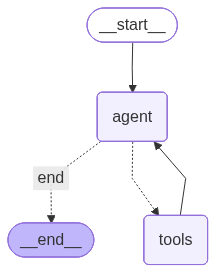

In [31]:
display(Image(business_agent.get_graph().draw_mermaid_png()))



### B. Langgraph implementation: Supervisor agent with Sub agent Nodes

In [52]:
from dataclasses import field

from typing import Annotated


In [58]:
def rag_agent_node(state: AgentState):
    """
    Answer User's business questions using provided Context.

    Args:
        state: current message state contains user query: AgentState

    """
    question = state["messages"][-1].content

    rag_results = retrieve_results(retriever, query=question)
    context     = get_rag_context(rag_results)
    metadata    = set([r.metadata['url'] for r in rag_results])

    prompt = f"""You are a business FAQ assistant and you answer business questions
                  using given context.
                 [Question]: {question}
                 [Context]: {context}"""

    response = llm.invoke(prompt)

    # writes back into graph state directly
    return {
        "messages": [AIMessage(content=response.content)],
        "metadata": metadata
    }



In [57]:
def sql_agent_node(state: AgentState) -> str:
    """
    Generate SQL code to answer User's business questions using provided Context.

    Args:
        state: current message state contains user query: AgentState

    """

    question = state["messages"][-1].content

    rag_results = retrieve_results(retriever, query=question)

    context = get_sql_context(rag_results)

    prompt = f"""You are SQL assitant and you answer business questions with valid SQL code
                  using given context which contains the schema for the various
                  tables. [Question]: {question} . [Context] {context}.
                  Return Only valid SQL code, do not generate any additional text. """


    response = llm.invoke(prompt)
    metadata = set([ result.metadata['url'] for result in rag_results] )


    # Return a dictionary with content and metadata directly
    return {
        "messages": [AIMessage(content=response.content)],
        "metadata": metadata
    }

In [53]:
class EDWAgentState(MessagesState):
    next_node: str = "rag_agent"
    metadata: set = field(default_factory=set)

In [54]:
VALID_NODES = {"rag_agent", "sql_agent", "END"}


In [55]:
# routing function (similar to should_continue()

def route_to_subagent(state: EDWAgentState) -> str:
    next_node = state.get("next_node", "rag_agent")

    if next_node not in VALID_NODES:
        print(f"[WARN] Supervisor returned unknown node '{next_node}', falling back to rag_agent")
        return "rag_agent"

    if next_node == "END":
        return "__end__"

    return next_node

In [ ]:
# Create SUpervisor Agent


from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser

SYSTEM_PROMPT = """You are a supervisor orchestrating a data warehouse assistant.
Based on the user question, decide which specialist agent should handle it next.

Available agents:
- rag_agent      : answers questions about table/column documentation,
                   schemas, what columns exist, what tables to use
- sql_agent      : writes and executes SQL queries when the user wants
                   actual data or calculations from the warehouse
- FINISH         : use when the final answer has already been provided
                   and nothing more is needed

Respond ONLY with valid JSON, no explanation:
{{"next_node": "rag_agent"}}
{{"next_node": "sql_agent"}}
{{"next_node": "END"}}
"""

supervisor_prompt = ChatPromptTemplate.from_messages([
    ("system", SYSTEM_PROMPT),
    ("placeholder", "{messages}"),   # injects full message history
])

def supervisor_agent(state: EDWAgentState):
    if not state["messages"]:
        raise ValueError("Empty state!")

    # plain llm — no tools bound, just needs to output a routing decision
    chain  = supervisor_prompt | llm | JsonOutputParser()

    result = chain.invoke({"messages": state["messages"]})
    print(f"[DEBUG] SUPERVISOR DECISION: {result}")

    next_node = result.get("next_node", "rag_agent")   # safe fallback

    return {
        "messages": state["messages"],   # supervisor doesn't add a message,
        "next_node": next_node           # just updates routing decision
    }

In [59]:
edw_graph = StateGraph(EDWAgentState)

# supervisor
edw_graph.add_node("supervisor", agent)

# sub-agents replace the single tool node: wired as a node, not a tool

edw_graph.add_node("rag_agent",  rag_agent_node)
edw_graph.add_node("sql_agent",  sql_agent_node)

# Graph entrypoint: supervisor node
edw_graph.set_entry_point("supervisor")

# supervisor routes to the right sub-agent
edw_graph.add_conditional_edges("supervisor", route_to_subagent, {
    "rag_agent":       "rag_agent",
    "sql_agent":       "sql_agent",
    "END":       "__end__"
})

# every sub-agent returns to supervisor after finishing
edw_graph.add_edge("rag_agent",       "supervisor")
edw_graph.add_edge("sql_agent",       "supervisor")




In [60]:
# compile multi agent graph
edw_agent = edw_graph.compile()

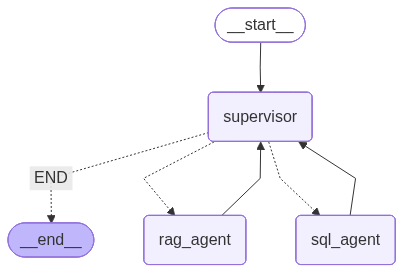

In [61]:
display(Image(edw_agent.get_graph().draw_mermaid_png()))
